In [1]:
# ==========================================
# Importing Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Display plots inside notebook
%matplotlib inline

# Set visualization style
sns.set_style("whitegrid")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# ==========================================
# Load the Dataset
# ==========================================

df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset loaded successfully!")

df.head()

Dataset loaded successfully!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# ==========================================
# Dataset Inspection
# ==========================================

print("="*50)
print("Shape of the Dataset")
print("="*50)
print(df.shape)

print("\n" + "="*50)
print("Columns in the Dataset")
print("="*50)
print(df.columns.tolist())

print("\n" + "="*50)
print("Data Types")
print("="*50)
print(df.dtypes)

print("\n" + "="*50)
print("First 5 Rows")
print("="*50)
display(df.head())

print("\n" + "="*50)
print("Last 5 Rows")
print("="*50)
display(df.tail())

Shape of the Dataset
(891, 12)

Columns in the Dataset
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

First 5 Rows


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Last 5 Rows


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [4]:
# ==========================================
# Missing Values & Duplicate Check
# ==========================================

print("="*50)
print("Missing Values")
print("="*50)
print(df.isnull().sum())

print("\n" + "="*50)
print("Duplicate Rows")
print("="*50)
print(df.duplicated().sum())

Missing Values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Rows
0


In [5]:
# ==========================================
# Data Cleaning
# ==========================================

# Fill missing Age values with Median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing Embarked values with Mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin column
df.drop('Cabin', axis=1, inplace=True)

print("✅ Data cleaning completed successfully!")

✅ Data cleaning completed successfully!


/tmp/ipykernel_1374/650666839.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1374/650666839.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [6]:
# ==========================================
# Verify Data Cleaning
# ==========================================

print("="*50)
print("Missing Values After Cleaning")
print("="*50)
print(df.isnull().sum())

print("\nDataset Shape After Cleaning:")
print(df.shape)

Missing Values After Cleaning
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Dataset Shape After Cleaning:
(891, 11)


In [8]:
# ==========================================
# Feature Engineering
# ==========================================

# Convert Sex column into numbers
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])

# Convert Embarked column into numbers
df['Embarked'] = LabelEncoder().fit_transform(df['Embarked'])

print("✅ Feature Engineering Completed!")

df.head()

✅ Feature Engineering Completed!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,2


In [9]:
# ==========================================
# Feature Selection
# ==========================================

# Drop unnecessary columns
df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

print("✅ Feature Selection Completed!")

print("\nRemaining Columns:")
print(df.columns.tolist())

df.head()

✅ Feature Selection Completed!

Remaining Columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [10]:
# ==========================================
# Train-Test Split
# ==========================================

# Features (X) and Target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("✅ Train-Test Split Completed!")

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

✅ Train-Test Split Completed!

Training Data Shape:
(712, 7)

Testing Data Shape:
(179, 7)


In [12]:
# ==========================================
# Model 1 - Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression

# Create the model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
lr_predictions = lr_model.predict(X_test)

print("✅ Logistic Regression Model Trained Successfully!")

✅ Logistic Regression Model Trained Successfully!


In [13]:
# ==========================================
# Logistic Regression Evaluation
# ==========================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)

print("📊 Logistic Regression Performance")
print("-" * 40)
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")

📊 Logistic Regression Performance
----------------------------------------
Accuracy : 0.8101
Precision: 0.7857
Recall   : 0.7432
F1 Score : 0.7639


In [14]:
# ==========================================
# Model 2 - Random Forest
# ==========================================

from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

print("✅ Random Forest Model Trained Successfully!")

✅ Random Forest Model Trained Successfully!


In [15]:
# ==========================================
# Random Forest Evaluation
# ==========================================

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("📊 Random Forest Performance")
print("-" * 40)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

📊 Random Forest Performance
----------------------------------------
Accuracy : 0.8212
Precision: 0.8088
Recall   : 0.7432
F1 Score : 0.7746


In [16]:
# ==========================================
# Model 3 - K-Nearest Neighbors (KNN)
# ==========================================

from sklearn.neighbors import KNeighborsClassifier

# Create the model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions
knn_predictions = knn_model.predict(X_test)

print("✅ KNN Model Trained Successfully!")

✅ KNN Model Trained Successfully!


In [17]:
# ==========================================
# KNN Evaluation
# ==========================================

knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_precision = precision_score(y_test, knn_predictions)
knn_recall = recall_score(y_test, knn_predictions)
knn_f1 = f1_score(y_test, knn_predictions)

print("📊 KNN Performance")
print("-" * 40)
print(f"Accuracy : {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall   : {knn_recall:.4f}")
print(f"F1 Score : {knn_f1:.4f}")

📊 KNN Performance
----------------------------------------
Accuracy : 0.7039
Precision: 0.6842
Recall   : 0.5270
F1 Score : 0.5954


In [18]:
# ==========================================
# Model Comparison Table
# ==========================================

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'K-Nearest Neighbors'
    ],
    'Accuracy': [
        lr_accuracy,
        rf_accuracy,
        knn_accuracy
    ],
    'Precision': [
        lr_precision,
        rf_precision,
        knn_precision
    ],
    'Recall': [
        lr_recall,
        rf_recall,
        knn_recall
    ],
    'F1 Score': [
        lr_f1,
        rf_f1,
        knn_f1
    ]
})

comparison = comparison.sort_values(by='Accuracy', ascending=False)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.821229,0.808824,0.743243,0.774648
0,Logistic Regression,0.810056,0.785714,0.743243,0.763889
2,K-Nearest Neighbors,0.703911,0.684211,0.527027,0.595420


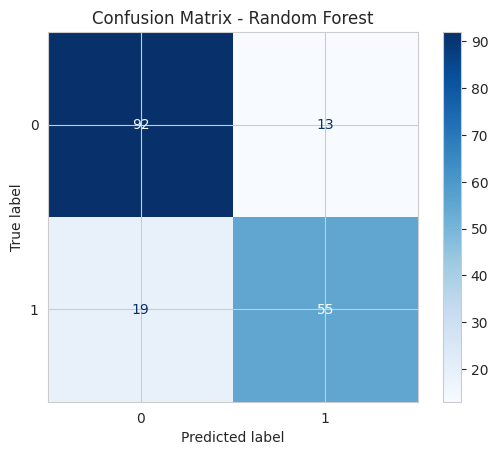

In [19]:
# ==========================================
# Confusion Matrix - Random Forest
# ==========================================

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap='Blues'
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

# 📌 Conclusion

This project developed and evaluated multiple Machine Learning models to predict Titanic passenger survival. Data preprocessing included handling missing values, encoding categorical variables, selecting relevant features, and splitting the dataset into training and testing sets.

Three classification algorithms were trained and compared: Logistic Regression, Random Forest, and K-Nearest Neighbors (KNN). Among them, the Random Forest Classifier achieved the best overall performance with an accuracy of **82.12%**, making it the most suitable model for this dataset.

The project demonstrates the complete Machine Learning workflow, from data preprocessing to model evaluation, and highlights the importance of feature engineering and model selection in improving prediction performance.

# 💡 Key Insights

- Random Forest achieved the highest accuracy (**82.12%**) among all evaluated models.
- Passenger class, gender, age, fare, and embarkation point contributed significantly to survival prediction.
- Proper handling of missing values improved the quality of the dataset.
- Feature engineering and feature selection played a major role in enhancing model performance.
- Comparing multiple algorithms helped identify the most effective model instead of relying on a single approach.

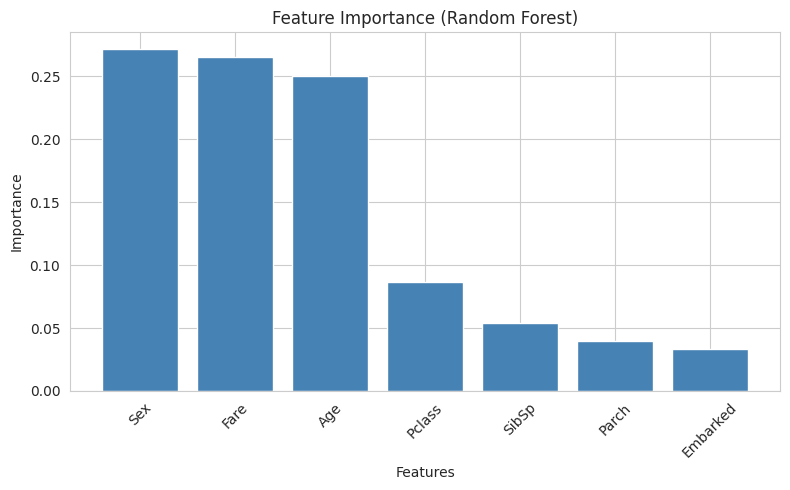

In [20]:
# ==========================================
# Feature Importance
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Plot
plt.figure(figsize=(8,5))
plt.bar(feature_importance['Feature'],
        feature_importance['Importance'],
        color='steelblue')

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

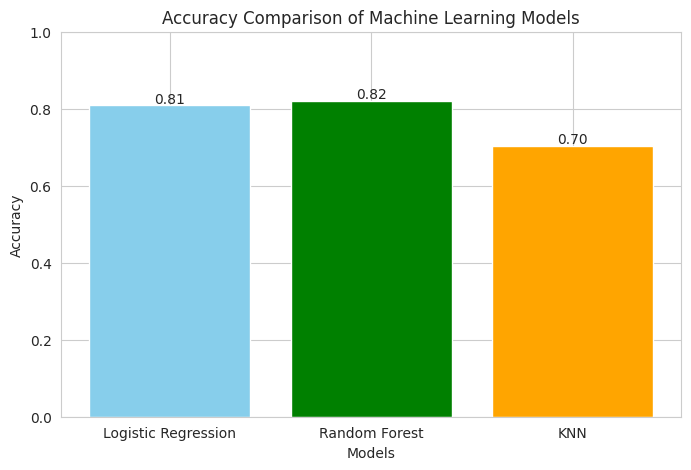

In [21]:
# ==========================================
# Model Accuracy Comparison
# ==========================================

models = [
    "Logistic Regression",
    "Random Forest",
    "KNN"
]

accuracies = [
    lr_accuracy,
    rf_accuracy,
    knn_accuracy
]

plt.figure(figsize=(8,5))

bars = plt.bar(
    models,
    accuracies,
    color=["skyblue", "green", "orange"]
)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.005,
        f"{y:.2f}",
        ha='center'
    )

plt.ylim(0,1)

plt.show()